# 2D Extension — Parametric Heat Conduction in a Plate (PET-PINN at Scale)

**Purpose.** The 1D study located the *lower* boundary of parameter-efficient
transfer: on a 922-parameter backbone, adapters saved parameters but cost
wall-clock time. The declared future work — and Prof. Frankel's request — is
the 2D extension: **does the sign of the comparison flip once the backbone is
wide?** Here the backbone has 4 hidden layers of width $d=50$ (7,851
parameters), so $r \ll d$ genuinely holds for the swept ranks.

**Problem.** Steady heat conduction (Laplace) in the unit plate with a
parametric heated bottom edge:

$$\nabla^2 T = 0,\qquad T(x,0) = a_1\sin(\pi x) + a_2\sin(2\pi x),
\qquad T=0 \text{ on the other edges.}$$

The exact solution is a two-mode superposition — closed form at **every**
operating point $\theta=(a_1,a_2)$, preserving the report's exact-benchmark
philosophy:

$$T(x,y) = a_1\sin(\pi x)\frac{\sinh(\pi(1-y))}{\sinh\pi}
        + a_2\sin(2\pi x)\frac{\sinh(2\pi(1-y))}{\sinh 2\pi}.$$

Pre-train at the single-mode source $(1.0, 0.0)$ and adapt to targets with
growing second-mode content: near $(1.0,0.3)$, medium $(0.7,0.7)$, far
$(0.2,1.3)$ — the far target is dominated by a mode the backbone has never
seen.

Set `QUICK = False` for the full report-quality run.

In [ ]:
import time
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 2026
print(DEVICE)

cuda


## Configuration

In [ ]:
# --- Run configuration ------------------------------------------------------
QUICK = False   # True = fast smoke test; False = full report-quality run

if QUICK:
    SEEDS = [2026, 7]
    PRE_ITERS, SCRATCH_ITERS, ADAPT_ITERS = 2000, 2000, 1000
    N_INT, N_BND = 20, 40          # interior grid n x n, boundary pts per edge
else:
    SEEDS = [2026, 7, 42]
    PRE_ITERS, SCRATCH_ITERS, ADAPT_ITERS = 10000, 10000, 3000
    N_INT, N_BND = 50, 100

SOURCE_PT = (1.0, 0.0)
TARGETS = [((1.0, 0.3), "near"),
           ((0.7, 0.7), "medium"),
           ((0.2, 1.3), "far")]
RANKS = [2, 4, 8]
WIDTH, DEPTH = 50, 4               # wide backbone: 4 hidden layers x 50

## Exact analytical solution (ground truth)

In [ ]:
# --- Analytical ground truth -------------------------------------------------
def analytical_solution_2d(x, y, a1, a2):
    """Exact Laplace solution for the parametric bottom-edge heating."""
    t1 = a1 * np.sin(np.pi * x) * np.sinh(np.pi * (1 - y)) / np.sinh(np.pi)
    t2 = a2 * np.sin(2*np.pi * x) * np.sinh(2*np.pi * (1 - y)) / np.sinh(2*np.pi)
    return t1 + t2

## Models
Same `Adapter` design as the 1D study (Eq. (1) of the report, $W_{down}$
zero-initialized), attached to a wide backbone.

In [ ]:
# --- Models -------------------------------------------------------------------
class Base2DPINN(nn.Module):
    """[2] -> DEPTH x [WIDTH] tanh -> [1]."""
    def __init__(self, width=WIDTH, depth=DEPTH):
        super().__init__()
        layers, d_in = [], 2
        for _ in range(depth):
            lin = nn.Linear(d_in, width)
            nn.init.xavier_normal_(lin.weight); nn.init.zeros_(lin.bias)
            layers.append(lin); d_in = width
        self.hidden = nn.ModuleList(layers)
        self.out = nn.Linear(d_in, 1)
        nn.init.xavier_normal_(self.out.weight); nn.init.zeros_(self.out.bias)

    def forward(self, xy):
        h = xy
        for lin in self.hidden:
            h = torch.tanh(lin(h))
        return self.out(h)

class Adapter(nn.Module):
    """h' = h + W_down GELU(W_up h); W_down zero-init (identity start)."""
    def __init__(self, d, r):
        super().__init__()
        self.up = nn.Linear(d, r)
        self.down = nn.Linear(r, d)
        nn.init.xavier_normal_(self.up.weight); nn.init.zeros_(self.up.bias)
        nn.init.zeros_(self.down.weight);       nn.init.zeros_(self.down.bias)
        self.act = nn.GELU()

    def forward(self, h):
        return h + self.down(self.act(self.up(h)))

class Adapted2DPINN(nn.Module):
    """Frozen Base2DPINN + one adapter after each hidden activation."""
    def __init__(self, base, r):
        super().__init__()
        self.base = base
        for p in self.base.parameters():
            p.requires_grad_(False)
        self.adapters = nn.ModuleList(
            [Adapter(lin.out_features, r) for lin in base.hidden])

    def forward(self, xy):
        h = xy
        for lin, ad in zip(self.base.hidden, self.adapters):
            h = ad(torch.tanh(lin(h)))
        return self.base.out(h)

def n_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Collocation points and boundary condition

In [ ]:
# --- Collocation points -------------------------------------------------------
def make_points(n_int=N_INT, n_bnd=N_BND):
    s = torch.linspace(0.0, 1.0, n_int + 2, device=DEVICE)[1:-1]
    gx, gy = torch.meshgrid(s, s, indexing="ij")
    XY_int = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1)
    t = torch.linspace(0.0, 1.0, n_bnd, device=DEVICE).reshape(-1, 1)
    z, o = torch.zeros_like(t), torch.ones_like(t)
    XY_bot = torch.cat([t, z], 1)     # y = 0 (heated)
    XY_top = torch.cat([t, o], 1)     # y = 1
    XY_lft = torch.cat([z, t], 1)     # x = 0
    XY_rgt = torch.cat([o, t], 1)     # x = 1
    return XY_int, XY_bot, torch.cat([XY_top, XY_lft, XY_rgt], 0)

XY_INT, XY_BOT, XY_ZERO = make_points()

def bottom_bc(x, a1, a2):
    return a1 * torch.sin(np.pi * x) + a2 * torch.sin(2*np.pi * x)

## Physics loss and training loop
Laplace residual via double automatic differentiation; identical
Adam + L-BFGS protocol and identical adaptation budget for full fine-tuning
and adapters — any wall-clock gap is per-iteration cost.

In [ ]:
# --- Physics loss and training ------------------------------------------------
def physics_loss(model, a1, a2):
    xy = XY_INT.clone().requires_grad_(True)
    T = model(xy)
    g = torch.autograd.grad(T.sum(), xy, create_graph=True)[0]
    Tx, Ty = g[:, 0:1], g[:, 1:2]
    Txx = torch.autograd.grad(Tx.sum(), xy, create_graph=True)[0][:, 0:1]
    Tyy = torch.autograd.grad(Ty.sum(), xy, create_graph=True)[0][:, 1:2]
    res = Txx + Tyy
    loss_pde = (res ** 2).mean()
    T_bot = model(XY_BOT)
    loss_bot = ((T_bot - bottom_bc(XY_BOT[:, 0:1], a1, a2)) ** 2).mean()
    loss_zero = (model(XY_ZERO) ** 2).mean()
    return loss_pde + loss_bot + loss_zero

def train(model, a1, a2, n_adam, tag=""):
    """Adam then L-BFGS on trainable params only. Returns (final_loss, wall)."""
    params = [p for p in model.parameters() if p.requires_grad]
    t0 = time.time()
    opt = torch.optim.Adam(params, lr=1e-3)
    for it in range(n_adam):
        opt.zero_grad()
        loss = physics_loss(model, a1, a2)
        loss.backward()
        opt.step()
    lbfgs = torch.optim.LBFGS(params, max_iter=300,
                              line_search_fn="strong_wolfe")
    def closure():
        lbfgs.zero_grad()
        l = physics_loss(model, a1, a2)
        l.backward()
        return l
    lbfgs.step(closure)
    wall = time.time() - t0
    final = physics_loss(model, a1, a2).item()
    print(f"[{tag}] final loss {final:.3e}   wall {wall:.1f}s   "
          f"trainable {n_trainable(model)}")
    return final, wall

def evaluate(model, a1, a2, n=100):
    """Relative L2 error against the exact solution on an n x n grid."""
    s = np.linspace(0, 1, n)
    gx, gy = np.meshgrid(s, s, indexing="ij")
    xy = torch.tensor(np.stack([gx.ravel(), gy.ravel()], 1), device=DEVICE)
    with torch.no_grad():
        pred = model(xy).cpu().numpy().ravel()
    exact = analytical_solution_2d(gx.ravel(), gy.ravel(), a1, a2)
    rel = np.linalg.norm(pred - exact) / np.linalg.norm(exact)
    return rel, gx, gy, pred.reshape(n, n), exact.reshape(n, n)

## Experiment grid (seeds × targets × methods)

In [ ]:
# --- Experiment ----------------------------------------------------------------
def run_all_methods_2d(base, target, seed):
    (a1, a2) = target
    rows = []
    rel, *_ = evaluate(base, a1, a2)
    rows.append(dict(method="No adaptation", rank=np.nan,
                     trainable=0, wall_s=0.0, relL2=rel))
    torch.manual_seed(seed)
    scratch = Base2DPINN().to(DEVICE)
    _, wall = train(scratch, a1, a2, SCRATCH_ITERS, tag=f"scratch/{seed}")
    rel, *_ = evaluate(scratch, a1, a2)
    rows.append(dict(method="From scratch", rank=np.nan,
                     trainable=n_trainable(scratch), wall_s=wall, relL2=rel))
    full_ft = copy.deepcopy(base)
    for p in full_ft.parameters():
        p.requires_grad_(True)
    _, wall = train(full_ft, a1, a2, ADAPT_ITERS, tag=f"full-FT/{seed}")
    rel, *_ = evaluate(full_ft, a1, a2)
    rows.append(dict(method="Full fine-tuning", rank=np.nan,
                     trainable=n_trainable(full_ft), wall_s=wall, relL2=rel))
    for r in RANKS:
        pet = Adapted2DPINN(copy.deepcopy(base), r=r).to(DEVICE)
        _, wall = train(pet, a1, a2, ADAPT_ITERS, tag=f"adapt r={r}/{seed}")
        rel, *_ = evaluate(pet, a1, a2)
        rows.append(dict(method="Adapters", rank=r,
                         trainable=n_trainable(pet), wall_s=wall, relL2=rel))
    return rows

def run_full_study_2d():
    records = []
    for seed in SEEDS:
        print(f"\n########## SEED {seed} ##########")
        torch.manual_seed(seed); np.random.seed(seed)
        base = Base2DPINN().to(DEVICE)
        train(base, *SOURCE_PT, PRE_ITERS, tag=f"pretrain/{seed}")
        rel_s, *_ = evaluate(base, *SOURCE_PT)
        print(f"    backbone source rel L2: {rel_s:.2e}")
        for (target, label) in TARGETS:
            print(f"  --- target {target} [{label}] ---")
            for row in run_all_methods_2d(base, target, seed):
                row.update(seed=seed, target=str(target), distance=label)
                records.append(row)
    return pd.DataFrame.from_records(records)

## Run the full study

In [ ]:
df2d = run_full_study_2d()
df2d.to_csv("results_2d_raw.csv", index=False)
print("\nSaved results_2d_raw.csv (", len(df2d), "rows )")

g = df2d.groupby(["distance", "method", "rank"], dropna=False)
summary2d = g.agg(relL2_mean=("relL2", "mean"), relL2_std=("relL2", "std"),
                  trainable=("trainable", "first"),
                  wall_mean=("wall_s", "mean"), wall_std=("wall_s", "std"),
                  n_seeds=("relL2", "count")).reset_index()
summary2d.to_csv("results_2d_summary.csv", index=False)
print(summary2d.to_string(index=False))


########## SEED 2026 ##########
[pretrain/2026] final loss 1.632e-05   wall 125.8s   trainable 7851
    backbone source rel L2: 4.44e-03
  --- target (1.0, 0.3) [near] ---
[scratch/2026] final loss 2.134e-04   wall 120.1s   trainable 7851
[full-FT/2026] final loss 2.580e-04   wall 40.3s   trainable 7851
[adapt r=2/2026] final loss 4.060e-04   wall 70.2s   trainable 1008
[adapt r=4/2026] final loss 1.296e-04   wall 81.8s   trainable 1816
[adapt r=8/2026] final loss 1.759e-04   wall 82.4s   trainable 3432
  --- target (0.7, 0.7) [medium] ---
[scratch/2026] final loss 3.731e-04   wall 116.9s   trainable 7851
[full-FT/2026] final loss 4.946e-04   wall 40.3s   trainable 7851
[adapt r=2/2026] final loss 2.917e-04   wall 81.1s   trainable 1008
[adapt r=4/2026] final loss 3.821e-04   wall 81.7s   trainable 1816
[adapt r=8/2026] final loss 1.078e-04   wall 81.7s   trainable 3432
  --- target (0.2, 1.3) [far] ---
[scratch/2026] final loss 1.813e-04   wall 117.8s   trainable 7851
[full-FT/2026] 

## The crossover question — wall-clock at scale
The single most important readout of this notebook: **is `Adapters` now
faster than `Full fine-tuning`?** In 1D (922 params) it was 1.6× slower.
Fu et al. report 72% faster at 3,063 params. This backbone: 7,851 params.

In [ ]:
piv = (df2d[df2d.method.isin(["Full fine-tuning", "From scratch"]) |
            ((df2d.method == "Adapters") & (df2d["rank"] == 4))]
        .groupby("method")
        .agg(wall_mean=("wall_s", "mean"), wall_std=("wall_s", "std"),
             relL2=("relL2", "mean"), trainable=("trainable", "first")))
print(piv.to_string())
ratio = (piv.loc["Adapters", "wall_mean"] /
         piv.loc["Full fine-tuning", "wall_mean"])
print(f"\nAdapters (r=4) / Full fine-tuning wall-clock ratio: {ratio:.2f}"
      f"  ({'adapters FASTER — sign flipped' if ratio < 1 else 'adapters still slower'})")

                   wall_mean  wall_std     relL2  trainable
method                                                     
Adapters           81.866395  0.573377  0.018214       1816
From scratch      117.678022  0.987396  0.017500       7851
Full fine-tuning   40.383780  0.248745  0.020799       7851

Adapters (r=4) / Full fine-tuning wall-clock ratio: 2.03  (adapters still slower)


## Figures

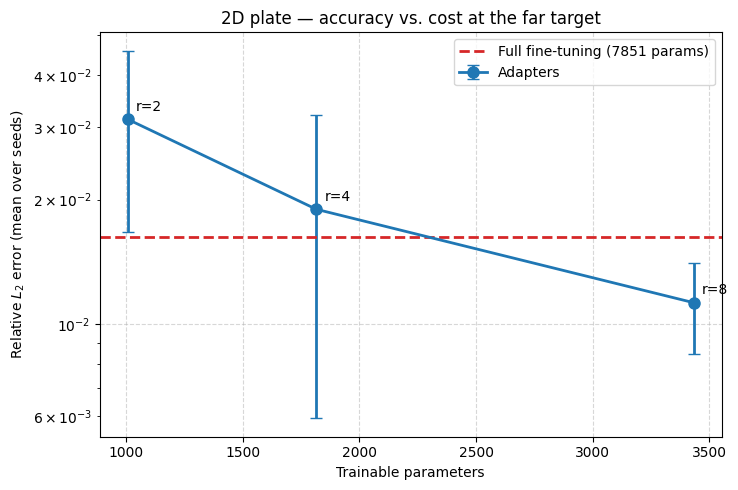

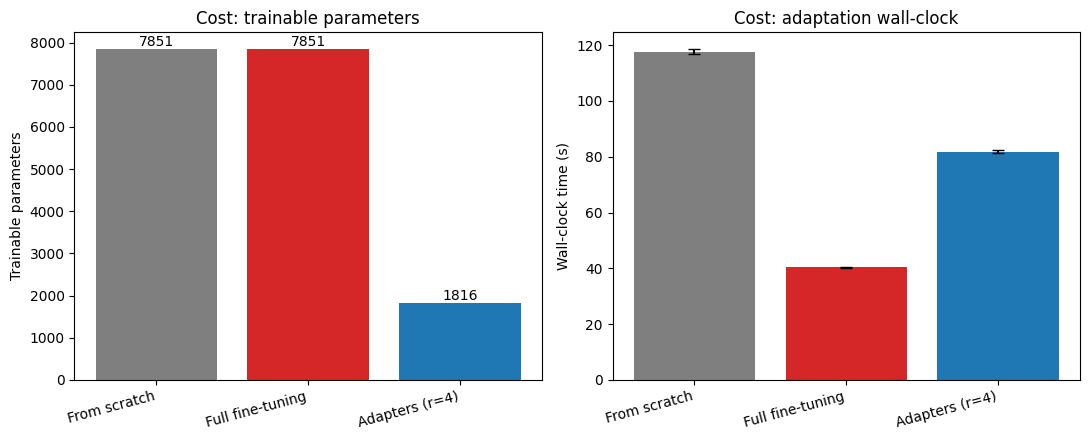

[contour-backbone] final loss 1.632e-05   wall 116.6s   trainable 7851
[contour-adapter] final loss 2.612e-04   wall 80.9s   trainable 1816


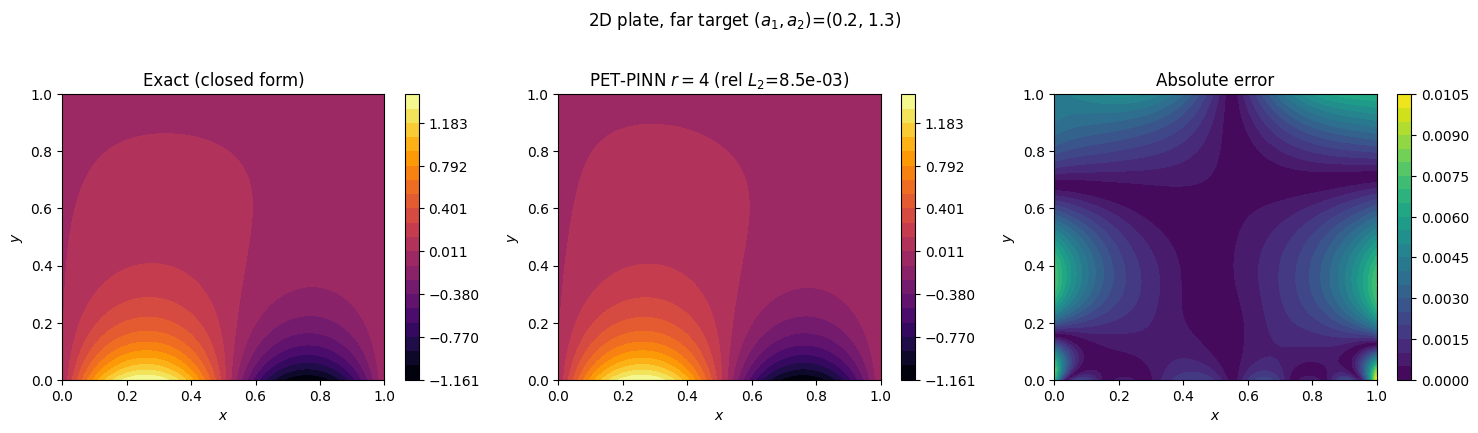

In [ ]:
# (1) Rank sweep at the far target
d = df2d[df2d.distance == "far"]
ad = (d[d.method == "Adapters"].groupby("rank")
      .agg(relL2=("relL2", "mean"), std=("relL2", "std"),
           params=("trainable", "first")).reset_index().sort_values("rank"))
ft = d[d.method == "Full fine-tuning"]
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.errorbar(ad.params, ad.relL2, yerr=ad["std"].fillna(0), marker="o", ms=8,
            lw=2, capsize=4, color="#1f77b4", label="Adapters")
for _, row in ad.iterrows():
    ax.annotate(f"r={int(row['rank'])}", (row.params, row.relL2),
                textcoords="offset points", xytext=(6, 6))
ax.axhline(ft.relL2.mean(), ls="--", lw=2, color="#d62728",
           label=f"Full fine-tuning ({int(ft.trainable.iloc[0])} params)")
ax.set_yscale("log"); ax.set_xlabel("Trainable parameters")
ax.set_ylabel("Relative $L_2$ error (mean over seeds)")
ax.set_title("2D plate — accuracy vs. cost at the far target")
ax.grid(True, ls="--", alpha=0.5); ax.legend()
fig.tight_layout(); fig.savefig("rank_sweep_2d_far.png", dpi=300); plt.show()

# (2) Wall-clock comparison
methods = ["From scratch", "Full fine-tuning", "Adapters (r=4)"]
sub = [df2d[df2d.method == "From scratch"],
       df2d[df2d.method == "Full fine-tuning"],
       df2d[(df2d.method == "Adapters") & (df2d["rank"] == 4)]]
walls = [s.wall_s.mean() for s in sub]; wstd = [s.wall_s.std() for s in sub]
params = [int(s.trainable.iloc[0]) for s in sub]
fig, (a1_, a2_) = plt.subplots(1, 2, figsize=(11, 4.5))
colors = ["#7f7f7f", "#d62728", "#1f77b4"]
a1_.bar(range(3), params, color=colors)
a1_.set_xticks(range(3)); a1_.set_xticklabels(methods, rotation=15, ha="right")
a1_.set_ylabel("Trainable parameters"); a1_.set_title("Cost: trainable parameters")
for xi, p in enumerate(params):
    a1_.text(xi, p, str(p), ha="center", va="bottom")
a2_.bar(range(3), walls, yerr=np.nan_to_num(wstd), capsize=4, color=colors)
a2_.set_xticks(range(3)); a2_.set_xticklabels(methods, rotation=15, ha="right")
a2_.set_ylabel("Wall-clock time (s)"); a2_.set_title("Cost: adaptation wall-clock")
fig.tight_layout(); fig.savefig("cost_comparison_2d.png", dpi=300); plt.show()

# (3) Contour: adapted solution vs exact at the far target
import copy as _copy
torch.manual_seed(SEED); np.random.seed(SEED)
_base = Base2DPINN().to(DEVICE)
train(_base, *SOURCE_PT, PRE_ITERS, tag="contour-backbone")
_far = TARGETS[-1][0]
_pet = Adapted2DPINN(_copy.deepcopy(_base), r=4).to(DEVICE)
train(_pet, *_far, ADAPT_ITERS, tag="contour-adapter")
rel, gx, gy, pred, exact = evaluate(_pet, *_far)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
lv = np.linspace(min(exact.min(), pred.min()), max(exact.max(), pred.max()), 21)
for axx, Z, tt in zip(axes[:2], [exact, pred],
                      ["Exact (closed form)", f"PET-PINN $r=4$ (rel $L_2$={rel:.1e})"]):
    cs = axx.contourf(gx, gy, Z, levels=lv, cmap="inferno")
    axx.set_title(tt); axx.set_xlabel("$x$"); axx.set_ylabel("$y$")
    fig.colorbar(cs, ax=axx)
err = np.abs(pred - exact)
cs = axes[2].contourf(gx, gy, err, levels=20, cmap="viridis")
axes[2].set_title("Absolute error"); axes[2].set_xlabel("$x$"); axes[2].set_ylabel("$y$")
fig.colorbar(cs, ax=axes[2])
fig.suptitle(f"2D plate, far target $(a_1,a_2)$={_far}", y=1.02)
fig.tight_layout(); fig.savefig("contours_2d_far.png", dpi=300, bbox_inches="tight"); plt.show()

## Download all outputs

In [12]:
from google.colab import files
for f in ["results_2d_raw.csv", "results_2d_summary.csv",
          "rank_sweep_2d_far.png", "cost_comparison_2d.png", "contours_2d_far.png"]:
    try:
        files.download(f)
    except Exception as e:
        print("skip", f, "->", e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>